<a href="https://colab.research.google.com/github/h77k/python-ai-Trunova-Polina/blob/main/notebooks/week3_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Week 3: Visualization — Визуализация

📥 [0] Подготовка данных: клонирование репозитория и загрузка CSV

**Что делаем:**
- Клонируем GitHub-репозиторий Полины в Google Colab
- Загружаем CSV-файлы:
  - `data/models.csv` — информация о моделях (тип, производитель, страна, дата выпуска, предшественники/наследники, размеры, масса)
  - `data/manufacturers.csv` — информация о производителях (страна, штаб-квартира, дата основания, отрасль)
- Приводим типы данных:
  - `startProduction` → `start_year` (целое число)
  - `predecessorLabel` / `successorLabel` — строки для построения графа родословной
  - `length`, `width`, `height`, `mass` → числовые значения
- Создаём производные признаки для визуализации поколений

**Результат:**
- Главная таблица `df_viz` (1 модель = 1 строка) с полями:
  - `model_name`, `type_name`, `manufacturer_name`, `country_name`, `start_year`
  - `predecessorLabel`, `successorLabel` — для построения lineage-графа
  - `length`, `width`, `height`, `mass`, `footprint`, `slenderness`
  - `manufacturer_inception_year`, `manufacturer_age_at_launch`
- Специальные выборки для графа родословной:
  - `df_lineage` — модели, у которых есть предшественник или наследник
  - `df_time` — модели с известным годом выпуска (ось X графа)

In [ ]:
# ============================================================
# ЯЧЕЙКА 1. Подготовка данных для Lab 3:
# чтение CSV, диагностика, безопасный merge, готовые выборки
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# --- Базовые настройки ---
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid", context="notebook")

# --- 1. Клонирование репозитория Полины ---
repo = "python-ai-Trunova-Polina"
repo_path = f"/content/{repo}"
if not os.path.exists(repo_path):
    !git clone -q https://github.com/h77k/{repo}.git
if os.getcwd() != repo_path:
    %cd {repo_path}
print(f"✅ Работаем в репозитории: {repo}")

# --- 2. Чтение исходных CSV ---
df_raw = pd.read_csv("data/models.csv")
df_mfr_raw = pd.read_csv("data/manufacturers.csv")
print(f"✅ models.csv: {len(df_raw)} строк")
print(f"✅ manufacturers.csv: {len(df_mfr_raw)} строк")

# --- 3. Переименование столбцов: models ---
# ИЗМЕНЕНО: точно соответствует структуре models.csv
df = df_raw.rename(columns={
    "model": "URL",                    # ← было model, стало URL
    "modelLabel": "model_name",        # ← было modelLabel
    "typeLabel": "type_name",          # ← было typeLabel
    "manufacturerLabel": "manufacturer_name",  # ← было manufacturerLabel
    "countryLabel": "country_name",    # ← было countryLabel
    "startProduction": "start_production",    # ← было startProduction
    "predecessorLabel": "predecessorLabel",   # оставляем как есть
    "successorLabel": "successorLabel",       # оставляем как есть
}, errors="ignore").copy()

# --- 4. Переименование столбцов: manufacturers ---
# ИЗМЕНЕНО: точно соответствует структуре manufacturers.csv
df_mfr = df_mfr_raw.rename(columns={
    "manufacturer": "manufacturer_url",        # ← было manufacturer
    "manufacturerLabel": "manufacturer_name",  # ← было manufacturerLabel
    "countryLabel": "mfr_country",             # ← было countryLabel
    "hqLabel": "hq_name",                      # ← было hqLabel
    "inception": "manufacturer_inception",     # ← было inception
    "industryLabel": "industry_name",          # ← было industryLabel
}, errors="ignore").copy()

# --- 5. Приведение типов: models ---
for col in ["length", "width", "height", "mass"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Обработка start_production -> start_year
if "start_production" in df.columns:
    df["start_production"] = pd.to_datetime(df["start_production"], errors="coerce", utc=True)
    df["start_year"] = df["start_production"].dt.year
else:
    df["start_year"] = np.nan

# --- 6. Приведение типов: manufacturers ---
if "manufacturer_inception" in df_mfr.columns:
    df_mfr["manufacturer_inception"] = pd.to_datetime(df_mfr["manufacturer_inception"], errors="coerce", utc=True)
    df_mfr["manufacturer_inception_year"] = df_mfr["manufacturer_inception"].dt.year
else:
    df_mfr["manufacturer_inception_year"] = np.nan

# --- 7. Гарантируем наличие ключевых столбцов для lineage графа ---
# ИЗМЕНЕНО: добавлены predecessorLabel и successorLabel как обязательные
needed_model_cols = [
    "URL", "model_name", "type", "type_name", "manufacturer", "manufacturer_name",
    "country_name", "start_production", "start_year",
    "predecessorLabel", "successorLabel",  # ключевые для графа родословной
    "length", "width", "height", "mass", "image"
]
for col in needed_model_cols:
    if col not in df.columns:
        df[col] = np.nan

needed_mfr_cols = [
    "manufacturer_url", "manufacturer_name", "mfr_country", "hq_name",
    "manufacturer_inception", "manufacturer_inception_year",
    "industry_name", "website_url", "logo_url", "mfr_image"
]
for col in needed_mfr_cols:
    if col not in df_mfr.columns:
        df_mfr[col] = np.nan

# --- 8. Диагностика длинного формата: models ---
n_rows_models = len(df)
n_unique_models = df["URL"].nunique(dropna=True)
avg_rows_per_model = n_rows_models / n_unique_models if n_unique_models else np.nan
model_dup_counts = df["URL"].value_counts(dropna=True)
dup_distribution = (
    model_dup_counts.value_counts()
    .sort_index()
    .rename_axis("строк_на_модель")
    .reset_index(name="сколько_моделей")
)
print("\n=== ДЛИННЫЙ ФОРМАТ: MODELS ===")
print(f"Всего строк: {n_rows_models}")
print(f"Уникальных моделей по URL: {n_unique_models}")
print(f"Среднее число строк на одну модель: {avg_rows_per_model:.2f}")
display(dup_distribution.head(10))

# --- 9. Диагностика длинного формата: manufacturers ---
n_rows_mfr = len(df_mfr)
n_unique_mfr = df_mfr["manufacturer_url"].nunique(dropna=True)
avg_rows_per_mfr = n_rows_mfr / n_unique_mfr if n_unique_mfr else np.nan
mfr_dup_counts = df_mfr["manufacturer_url"].value_counts(dropna=True)
mfr_dup_distribution = (
    mfr_dup_counts.value_counts()
    .sort_index()
    .rename_axis("строк_на_производителя")
    .reset_index(name="сколько_производителей")
)
print("\n=== ДЛИННЫЙ ФОРМАТ: MANUFACTURERS ===")
print(f"Всего строк: {n_rows_mfr}")
print(f"Уникальных производителей по manufacturer_url: {n_unique_mfr}")
print(f"Среднее число строк на одного производителя: {avg_rows_per_mfr:.2f}")
display(mfr_dup_distribution.head(10))

# --- 10. Fill Rate: models ---
optional_model_cols = [
    "type_name", "country_name", "start_year",
    "predecessorLabel", "successorLabel",
    "length", "width", "height", "mass", "image"
]
optional_model_cols = [c for c in optional_model_cols if c in df.columns]
fill_rate_models = (
    pd.Series({c: df[c].notna().mean() * 100 for c in optional_model_cols}, name="fill_rate_%")
    .sort_values(ascending=False)
    .round(1)
    .reset_index()
    .rename(columns={"index": "field"})
)

# --- 11. Fill Rate: manufacturers ---
optional_mfr_cols = [
    "mfr_country", "hq_name", "manufacturer_inception_year",
    "industry_name", "website_url", "logo_url", "mfr_image"
]
optional_mfr_cols = [c for c in optional_mfr_cols if c in df_mfr.columns]
fill_rate_mfr = (
    pd.Series({c: df_mfr[c].notna().mean() * 100 for c in optional_mfr_cols}, name="fill_rate_%")
    .sort_values(ascending=False)
    .round(1)
    .reset_index()
    .rename(columns={"index": "field"})
)
print("\n=== FILL RATE: MODELS ===")
display(fill_rate_models)
print("\n=== FILL RATE: MANUFACTURERS ===")
display(fill_rate_mfr)

rare_model_fields = fill_rate_models.loc[fill_rate_models["fill_rate_%"] < 15, "field"].tolist()
rare_mfr_fields = fill_rate_mfr.loc[fill_rate_mfr["fill_rate_%"] < 15, "field"].tolist()
print("Редкие поля models (<15%):", rare_model_fields if rare_model_fields else "нет")
print("Редкие поля manufacturers (<15%):", rare_mfr_fields if rare_mfr_fields else "нет")

# --- 12. Проверка QID вместо читаемой метки в type_name ---
type_labels = (
    df[["URL", "type_name"]]
    .dropna()
    .drop_duplicates()
    .copy()
)
type_labels["is_qid_type"] = type_labels["type_name"].astype(str).str.fullmatch(r"Q\d+")
qid_type_share = type_labels["is_qid_type"].mean() * 100 if len(type_labels) else np.nan
print(f"\nДоля type_name, которые выглядят как QID: {qid_type_share:.1f}%")
qid_examples = type_labels[type_labels["is_qid_type"]].head(10)
if not qid_examples.empty:
    print("Примеры type_name = QID:")
    display(qid_examples)

# --- 13. Создаём df_unique: одна строка на одну модель ---
df["_nonnull_count"] = df.notna().sum(axis=1)
df_unique = (
    df.sort_values(["URL", "_nonnull_count"], ascending=[True, False])
      .drop_duplicates(subset="URL")
      .drop(columns="_nonnull_count")
      .copy()
)

# --- 14. Сохраняем информацию о многозначных типах отдельно ---
def unique_list(series):
    vals = [x for x in series.dropna().astype(str).str.strip() if x]
    vals = sorted(set(vals))
    return vals

def first_mode_or_first(series):
    s = series.dropna().astype(str).str.strip()
    s = s[s != ""]
    if s.empty:
        return np.nan
    mode = s.mode()
    return mode.iloc[0] if not mode.empty else s.iloc[0]

df_model_types = (
    df.groupby("URL", dropna=True)
      .agg(
          n_type_rows=("type_name", "count"),
          n_types=("type_name", pd.Series.nunique),
          type_names=("type_name", unique_list),
          primary_type=("type_name", first_mode_or_first)
      )
      .reset_index()
)

# --- 15. Готовим уникальную таблицу производителей ---
df_mfr_industry = (
    df_mfr.groupby("manufacturer_url", dropna=True)
          .agg(
              n_industries=("industry_name", pd.Series.nunique),
              industry_names=("industry_name", unique_list),
              primary_industry=("industry_name", first_mode_or_first)
          )
          .reset_index()
)

df_mfr_unique = (
    df_mfr.groupby("manufacturer_url", dropna=True)
          .agg(
              manufacturer_name=("manufacturer_name", "first"),
              mfr_country=("mfr_country", "first"),
              hq_name=("hq_name", "first"),
              manufacturer_inception=("manufacturer_inception", "first"),
              manufacturer_inception_year=("manufacturer_inception_year", "first"),
              website_url=("website_url", "first"),
              logo_url=("logo_url", "first"),
              mfr_image=("mfr_image", "first")
          )
          .reset_index()
          .merge(df_mfr_industry, on="manufacturer_url", how="left", validate="one_to_one")
)

# --- 16. Безопасный merge для визуализации ---
rows_before_merge = len(df_unique)
df_viz = df_unique.merge(
    df_model_types,
    on="URL",
    how="left",
    validate="one_to_one"
)
df_viz = df_viz.merge(
    df_mfr_unique,
    left_on="manufacturer",
    right_on="manufacturer_url",
    how="left",
    validate="many_to_one",
    indicator="_mfr_merge"
)

print("\n=== ПРОВЕРКА MERGE ===")
print(f"Строк до merge: {rows_before_merge}")
print(f"Строк после merge: {len(df_viz)}")
print(f"Уникальных моделей после merge: {df_viz['URL'].nunique(dropna=True)}")
print("Статус совпадений по производителям:")
display(df_viz["_mfr_merge"].value_counts(dropna=False).rename_axis("merge_status").reset_index(name="rows"))

# --- 17. Производные признаки для графа родословной и временной оси ---
for col in ["length", "width", "height", "mass", "start_year", "manufacturer_inception_year"]:
    if col in df_viz.columns:
        df_viz[col] = pd.to_numeric(df_viz[col], errors="coerce")

df_viz["footprint"] = df_viz["length"] * df_viz["width"]
df_viz["slenderness"] = df_viz["length"] / df_viz["width"]
df_viz["height_to_width"] = df_viz["height"] / df_viz["width"]
df_viz["manufacturer_age_at_launch"] = df_viz["start_year"] - df_viz["manufacturer_inception_year"]

# Защита от бессмысленных значений
df_viz.loc[df_viz["manufacturer_age_at_launch"] < 0, "manufacturer_age_at_launch"] = np.nan
df_viz.loc[df_viz["slenderness"] <= 0, "slenderness"] = np.nan
df_viz.loc[df_viz["height_to_width"] <= 0, "height_to_width"] = np.nan
df_viz.loc[df_viz["footprint"] <= 0, "footprint"] = np.nan

# --- 18. Удобное поле типа для графиков (очищаем от QID) ---
df_viz["type_for_viz"] = df_viz["primary_type"].copy()
df_viz["type_for_viz"] = df_viz["type_for_viz"].where(
    ~df_viz["type_for_viz"].astype(str).str.fullmatch(r"Q\d+"),
    np.nan
)

# --- 19. Отдельная таблица частот типов без QID ---
df_types_readable = (
    df[["URL", "type_name"]]
    .dropna()
    .drop_duplicates()
    .copy()
)
df_types_readable = df_types_readable[
    ~df_types_readable["type_name"].astype(str).str.fullmatch(r"Q\d+")
]
df_type_counts = (
    df_types_readable["type_name"]
    .value_counts()
    .rename_axis("type_name")
    .reset_index(name="n_models")
)

# "Ядро" данных: типы, где хотя бы 10 моделей
core_types = df_type_counts.loc[df_type_counts["n_models"] >= 10, "type_name"].tolist()
core_urls = (
    df_types_readable[df_types_readable["type_name"].isin(core_types)]["URL"]
    .drop_duplicates()
)
df_core = df_viz[df_viz["URL"].isin(core_urls)].copy()

# --- 20. ГОТОВЫЕ ВЫБОРКИ ДЛЯ ГРАФА ТЕХНОЛОГИЧЕСКОЙ РОДОСЛОВНОЙ ---
# ИЗМЕНЕНО: созданы выборки, которые точно нужны для time-DAG по методичке
df_time = df_viz[df_viz["start_year"].notna()].copy()
df_dims = df_viz[
    df_viz[["length", "width", "height"]].notna().all(axis=1)
].copy()
df_mass = df_viz[df_viz["mass"].notna()].copy()

# КЛЮЧЕВАЯ ВЫБОРКА ДЛЯ ГРАФА: модели, у которых есть lineage-связи
df_lineage = df_viz[
    df_viz[["predecessorLabel", "successorLabel"]].notna().any(axis=1)
].copy()

df_mfr_age = df_viz[
    df_viz[["start_year", "manufacturer_inception_year", "manufacturer_age_at_launch"]].notna().all(axis=1)
].copy()

# ДОПОЛНИТЕЛЬНО: выборка для графа с известным годом И lineage
df_lineage_time = df_viz[
    df_viz["start_year"].notna() &
    df_viz[["predecessorLabel", "successorLabel"]].notna().any(axis=1)
].copy()
print(f"\n✅ Для time-DAG графа: {len(df_lineage_time)} моделей с годом выпуска и lineage-связями")

# --- 21. Короткая сводка для выбора графиков ---
sample_summary = pd.DataFrame({
    "dataset": ["df_viz", "df_core", "df_time", "df_dims", "df_mass", "df_lineage", "df_mfr_age", "df_lineage_time"],
    "rows": [
        len(df_viz),
        len(df_core),
        len(df_time),
        len(df_dims),
        len(df_mass),
        len(df_lineage),
        len(df_mfr_age),
        len(df_lineage_time)
    ],
    "description": [
        "1 строка = 1 модель, основная таблица для Lab 3",
        "модели из часто встречающихся читаемых типов",
        "есть год начала производства (для оси X графа)",
        "есть длина, ширина и высота",
        "есть масса",
        "🌟 есть predecessor и/или successor — основа для графа родословной",
        "известен возраст производителя на момент запуска модели",
        "🌟 time-DAG: есть И год, И lineage-связи"
    ]
})
print("\n=== ГОТОВЫЕ ВЫБОРКИ ДЛЯ ГРАФИКОВ ===")
display(sample_summary)

# --- 22. Мини-диагностика выбросов для числовых полей ---
numeric_cols = ["start_year", "length", "width", "height", "mass", "footprint", "slenderness", "manufacturer_age_at_launch"]
numeric_cols = [c for c in numeric_cols if c in df_viz.columns]
outlier_report = []
for col in numeric_cols:
    s = df_viz[col].dropna()
    if len(s) >= 5:
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        low = q1 - 1.5 * iqr
        high = q3 + 1.5 * iqr
        n_out = ((df_viz[col] < low) | (df_viz[col] > high)).sum()
        outlier_report.append([col, round(low, 2), round(high, 2), int(n_out)])
outlier_report = pd.DataFrame(outlier_report, columns=["field", "low_iqr", "high_iqr", "n_outliers"])
print("\n=== ПРЕДВАРИТЕЛЬНАЯ ДИАГНОСТИКА ВЫБРОСОВ ===")
display(outlier_report)

# --- 23. Финальные объекты, с которыми удобно работать дальше ---
print("\n✅ Готово.")
print("Основные DataFrame:")
print("- df_raw, df_mfr_raw  -> сырые CSV")
print("- df, df_mfr          -> очищенные длинные таблицы")
print("- df_unique           -> 1 строка = 1 модель")
print("- df_mfr_unique       -> 1 строка = 1 производитель")
print("- df_viz              -> главная таблица для визуализаций")
print("- df_core, df_time, df_dims, df_mass, df_mfr_age -> готовые подвыборки")
print("- 🌟 df_lineage       -> модели с lineage-связями (для графа родословной)")
print("- 🌟 df_lineage_time  -> time-DAG: год + lineage (рекомендован преподавателем)")

/content/python-ai-Trunova-Polina
✅ Работаем в репозитории: python-ai-Trunova-Polina
✅ models.csv: 1929 строк
✅ manufacturers.csv: 18 строк

=== ДЛИННЫЙ ФОРМАТ: MODELS ===
Всего строк: 1929
Уникальных моделей по URL: 1666
Среднее число строк на одну модель: 1.16


,строк_на_модель,сколько_моделей
0,1,1474
1,2,165
2,3,3
3,4,20
4,6,2
5,8,1
6,16,1



=== ДЛИННЫЙ ФОРМАТ: MANUFACTURERS ===
Всего строк: 18
Уникальных производителей по manufacturer_url: 9
Среднее число строк на одного производителя: 2.00


,строк_на_производителя,сколько_производителей
0,1,3
1,2,4
2,3,1
3,4,1



=== FILL RATE: MODELS ===


...


✅ Для time-DAG графа: 12 моделей с годом выпуска и lineage-связями

=== ГОТОВЫЕ ВЫБОРКИ ДЛЯ ГРАФИКОВ ===


,dataset,rows,description
0,df_viz,1666,"1 строка = 1 модель, основная таблица для Lab 3"
1,df_core,1535,модели из часто встречающихся читаемых типов
2,df_time,23,есть год начала производства (для оси X графа)
3,df_dims,305,"есть длина, ширина и высота"
4,df_mass,163,есть масса
5,df_lineage,712,🌟 есть predecessor и/или successor — основа дл...
6,df_mfr_age,22,известен возраст производителя на момент запус...
7,df_lineage_time,12,"🌟 time-DAG: есть И год, И lineage-связи"



=== ПРЕДВАРИТЕЛЬНАЯ ДИАГНОСТИКА ВЫБРОСОВ ===


,field,low_iqr,high_iqr,n_outliers
0,start_year,1966.50,2042.50,4
1,length,2920.50,6120.50,32
2,width,1370.00,2210.00,32
3,height,1000.25,2054.25,35
4,mass,-281.00,2975.00,10
5,footprint,3608155.12,12681508.12,25
6,slenderness,2.00,3.09,14
7,manufacturer_age_at_launch,-86.00,200.00,0



✅ Готово.
Основные DataFrame:
- df_raw, df_mfr_raw  -> сырые CSV
- df, df_mfr          -> очищенные длинные таблицы
- df_unique           -> 1 строка = 1 модель
- df_mfr_unique       -> 1 строка = 1 производитель
- df_viz              -> главная таблица для визуализаций
- df_core, df_time, df_dims, df_mass, df_mfr_age -> готовые подвыборки
- 🌟 df_lineage       -> модели с lineage-связями (для графа родословной)
- 🌟 df_lineage_time  -> time-DAG: год + lineage (рекомендован преподавателем)


In [ ]:
# ============================================================
# ЯЧЕЙКА 2. Быстрая проверка данных для графа родословной
# ============================================================

print("🔍 БЫСТРАЯ ДИАГНОСТИКА ДЛЯ TIME-DAG (ВАРИАНТ 1 ПРЕПОДАВАТЕЛЯ)")
print("=" * 60)

# 1. Общая статистика по lineage
n_with_predecessor = df_viz["predecessorLabel"].notna().sum()
n_with_successor = df_viz["successorLabel"].notna().sum()
n_with_any_lineage = df_lineage.shape[0]

print(f"\n📊 Статистика lineage-связей:")
print(f"   - Моделей с predecessorLabel: {n_with_predecessor}")
print(f"   - Моделей с successorLabel: {n_with_successor}")
print(f"   - Моделей хотя бы с одной связью: {n_with_any_lineage}")

# 2. Статистика для time-DAG
print(f"\n📊 Статистика для time-DAG (ось X = год):")
print(f"   - Моделей с известным годом: {len(df_time)}")
print(f"   - Моделей с годом И lineage: {len(df_lineage_time)}")
print(f"   - Процент от всех моделей: {len(df_lineage_time)/len(df_viz)*100:.1f}%")

# 3. Примеры связей для проверки структуры
print("\n🔗 Примеры lineage-связей (первые 10):")
lineage_examples = df_viz[
    df_viz["predecessorLabel"].notna() | df_viz["successorLabel"].notna()
][["model_name", "type_name", "start_year", "predecessorLabel", "successorLabel"]].head(10)
display(lineage_examples)

# 4. Распределение по десятилетиям (для черновика B по методичке)
df_lineage_time["decade"] = (df_lineage_time["start_year"] // 10) * 10
decade_counts = df_lineage_time["decade"].value_counts().sort_index()
print("\n📅 Распределение моделей с lineage по десятилетиям:")
for decade, count in decade_counts.items():
    print(f"   {int(decade)}-е: {count} моделей")

# 5. Предупреждение о разреженности (если нужно)
if len(df_lineage_time) < 30:
    print("\n⚠️ ВНИМАНИЕ: выборка для time-DAG небольшая (<30 моделей).")
    print("   Преподаватель рекомендует:")
    print("   - Черновик B: группировка по десятилетиям")
    print("   - Черновик C: только крупнейшие компоненты графа")
    print("   - Полный граф может выглядеть как 'лапша' — это нормально для черновика A")

print("\n✅ Диагностика завершена. Можно переходить к построению time-DAG.")
print("Рекомендуемый порядок черновиков (по методичке):")
print("   1. Черновик A: полный time-DAG (даже если лапша)")
print("   2. Черновик B: по десятилетиям")
print("   3. Черновик C: только крупнейшие компоненты")

🔍 БЫСТРАЯ ДИАГНОСТИКА ДЛЯ TIME-DAG (ВАРИАНТ 1 ПРЕПОДАВАТЕЛЯ)

📊 Статистика lineage-связей:
   - Моделей с predecessorLabel: 560
   - Моделей с successorLabel: 510
   - Моделей хотя бы с одной связью: 712

📊 Статистика для time-DAG (ось X = год):
   - Моделей с известным годом: 23
   - Моделей с годом И lineage: 12
   - Процент от всех моделей: 0.7%

🔗 Примеры lineage-связей (первые 10):


,model_name,type_name,start_year,predecessorLabel,successorLabel
0,ГАЗ-53,модель грузовика,NaN,ГАЗ-51,ГАЗ-3307
9,Volkswagen Bora (Китай),модель автомобиля,NaN,Volkswagen New Bora,NaN
44,Mercedes-Benz 170S,модель автомобиля,NaN,Mercedes-Benz W136,NaN
45,Ford Pinto,модель автомобиля,NaN,Ford Cortina,Ford Escort (Северная Америка)
55,Maybach 62,модель автомобиля,NaN,Mercedes-Benz W100,Mercedes-Benz S-Класс
67,Chrysler Pacifica,модель автомобиля,NaN,NaN,Dodge Journey
71,Škoda Slavia,модель автомобиля,NaN,Škoda Rapid (2011),NaN
72,"Ford Ranger (T6, first generation)",модель автомобиля,NaN,NaN,"Ford Ranger (T6, second generation)"
73,"Ford Ranger (T6, second generation)",модель автомобиля,NaN,"Ford Ranger (T6, first generation)",NaN
76,Mercedes-Benz W415,модель автомобиля,NaN,Mercedes-Benz Vaneo,NaN



📅 Распределение моделей с lineage по десятилетиям:
   1900-е: 1 моделей
   1930-е: 1 моделей
   1940-е: 1 моделей
   1960-е: 1 моделей
   1970-е: 1 моделей
   1990-е: 1 моделей
   2000-е: 3 моделей
   2010-е: 3 моделей

⚠️ ВНИМАНИЕ: выборка для time-DAG небольшая (<30 моделей).
   Преподаватель рекомендует:
   - Черновик B: группировка по десятилетиям
   - Черновик C: только крупнейшие компоненты графа
   - Полный граф может выглядеть как 'лапша' — это нормально для черновика A

✅ Диагностика завершена. Можно переходить к построению time-DAG.
Рекомендуемый порядок черновиков (по методичке):
   1. Черновик A: полный time-DAG (даже если лапша)
   2. Черновик B: по десятилетиям
   3. Черновик C: только крупнейшие компоненты


📊 Строим граф на 12 моделях с известным годом и lineage
🔗 Построено 16 уникальных связей предшественник→наследник
🌐 Граф: 26 узлов, 16 рёбер


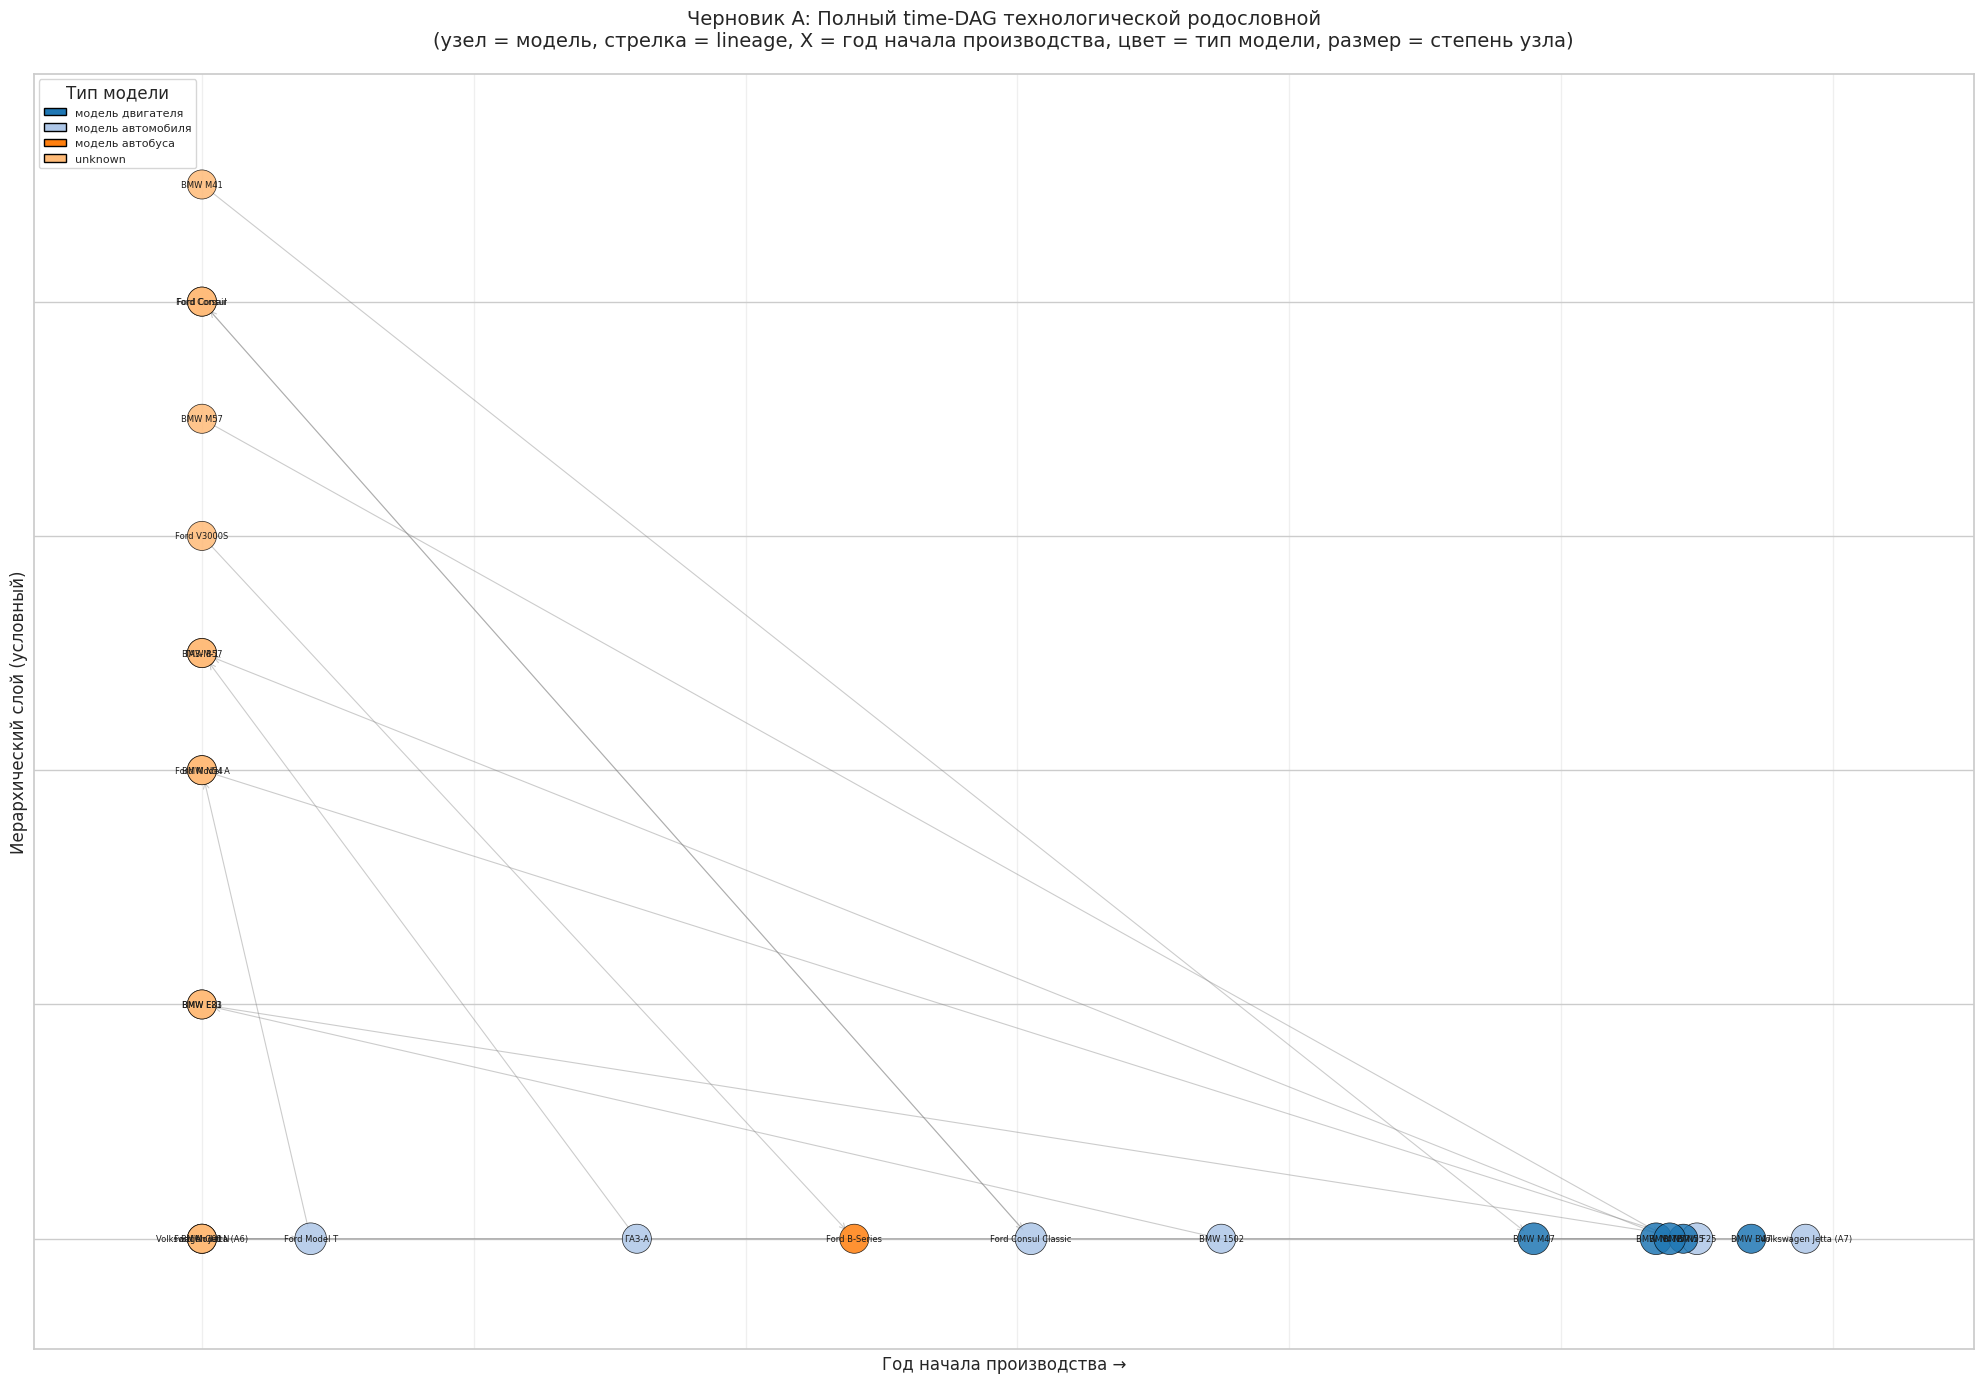


📌 ВЕРДИКТ ЧЕРНОВИКА A:
   - Узлов: 26
   - Рёбер: 16
   - Проблема: читаемо


In [ ]:
# ============================================================
# ЯЧЕЙКА 3. Черновик A: полный time-DAG (направленный граф)
# ============================================================
# Преподаватель: «Полный граф всех связанных моделей»
# Исследовательский вопрос: как модели наследуют друг друга во времени?

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

# --- 1. Подготовка данных для графа ---
# Берём выборку с известным годом И lineage-связями
gdf = df_lineage_time.copy()
print(f"📊 Строим граф на {len(gdf)} моделях с известным годом и lineage")

# --- 2. Построение списка рёбер (predecessor → successor) ---
edges = []
nodes_with_year = {}

for _, row in gdf.iterrows():
    model = row["model_name"]
    start_year = row["start_year"]

    if pd.notna(start_year):
        nodes_with_year[model] = start_year

    # predecessor → текущая модель
    if pd.notna(row["predecessorLabel"]):
        pred = row["predecessorLabel"]
        edges.append((pred, model))

    # текущая модель → successor
    if pd.notna(row["successorLabel"]):
        succ = row["successorLabel"]
        edges.append((model, succ))

# Удаляем дубликаты рёбер
edges = list(set(edges))
print(f"🔗 Построено {len(edges)} уникальных связей предшественник→наследник")

# --- 3. Создание графа ---
G = nx.DiGraph()
G.add_edges_from(edges)

# Добавляем атрибуты узлов (год, тип, размер)
for node in G.nodes():
    if node in nodes_with_year:
        G.nodes[node]["year"] = nodes_with_year[node]
    else:
        G.nodes[node]["year"] = np.nan

    # Добавляем тип модели, если есть
    type_info = gdf[gdf["model_name"] == node]["type_for_viz"].iloc[0] if node in gdf["model_name"].values else None
    G.nodes[node]["type"] = type_info if pd.notna(type_info) else "unknown"

    # Степень узла (influence)
    G.nodes[node]["degree"] = G.in_degree(node) + G.out_degree(node)

print(f"🌐 Граф: {G.number_of_nodes()} узлов, {G.number_of_edges()} рёбер")

# --- 4. Визуализация полного time-DAG ---
plt.figure(figsize=(20, 14))

# Позиционирование: X = год, Y = иерархический слой
pos = {}
for node in G.nodes():
    year = G.nodes[node]["year"]
    if pd.notna(year):
        # Группируем узлы с одинаковым годом по вертикали
        same_year_nodes = [n for n in G.nodes() if G.nodes[n].get("year") == year]
        y_idx = same_year_nodes.index(node) if node in same_year_nodes else 0
        pos[node] = (year, -y_idx * 2)  # отрицательный Y для читаемости
    else:
        pos[node] = (1900, -len(pos) % 10)  # fallback

# Цветовая схема по типу модели
types = list(set(nx.get_node_attributes(G, "type").values()))
type_colors = plt.cm.tab20.colors[:len(types)]
color_map = {t: type_colors[i] for i, t in enumerate(types)}
node_colors = [color_map.get(G.nodes[n]["type"], "#cccccc") for n in G.nodes()]

# Размер узлов по степени (log scale)
node_sizes = [300 + 200 * np.log1p(G.nodes[n]["degree"]) for n in G.nodes()]

# Рисуем граф
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.85, edgecolors="black", linewidths=0.5)
nx.draw_networkx_edges(G, pos, edge_color="gray", alpha=0.4, arrows=True, arrowsize=10, arrowstyle="->", width=0.8)
nx.draw_networkx_labels(G, pos, font_size=6, font_family="sans-serif")

# Оформление
plt.title("Черновик A: Полный time-DAG технологической родословной\n(узел = модель, стрелка = lineage, X = год начала производства, цвет = тип модели, размер = степень узла)",
          fontsize=14, pad=20)
plt.xlabel("Год начала производства →", fontsize=12)
plt.ylabel("Иерархический слой (условный)", fontsize=12)
plt.grid(True, axis="x", alpha=0.3)

# Легенда по типам
legend_elements = [Patch(facecolor=color_map[t], edgecolor="black", label=t) for t in list(color_map.keys())[:15]]
if len(legend_elements) > 0:
    plt.legend(handles=legend_elements, loc="upper left", fontsize=8, title="Тип модели")

plt.tight_layout()
plt.savefig("draft_A_full_time_DAG.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n📌 ВЕРДИКТ ЧЕРНОВИКА A:")
print("   - Узлов:", G.number_of_nodes())
print("   - Рёбер:", G.number_of_edges())
print("   - Проблема:", "лапша" if G.number_of_nodes() > 50 else "читаемо")